# Triaxial vs Spherical NFW — Stacked ΔΣ Demo

This notebook demonstrates the triaxial NFW shear functions added to `xlensing.sims`.
We stack **1 000 cluster fields**, each backed by a metacalibration-format source
catalog, and compare the recovered stacked excess surface mass density ΔΣ(R) for:

1. **Spherical NFW** — the reference case.
2. **Triaxial NFW with random orientations** — each cluster has random CDM-like axis
   ratios and an isotropically-drawn line-of-sight direction.

### Key design choices

* All 1 000 realizations share the **same galaxy positions and redshifts**.  Only the
  intrinsic ellipticities are re-drawn per cluster (equivalent to 1 000 independent
  source-catalog noise realizations).
* Expensive geometry (σ_crit, radii, polar angles) is **pre-computed once**, making
  the stacking loop fast despite 1 000 iterations.
* Metacal responses are derived from a **lognormal galaxy-size distribution**: 
  R11 = R22 = 1 − (size/size_scale)², R12 = R21 = 0.

In [1]:
import numpy as np
import matplotlib.pyplot as plt

from xlensing.sims import (
    make_simple_random_cat,
    equatorial_to_polar,   # (lon1_cluster, lat1, lon2_source, lat2) → sep, theta
    add_shears,
    r_vir, NFW_delta_c, rhoM, gNFW,
    project_ellipsoid,
)
from xlensing.data import stacked_signal, sigmacrit as sc_data
from xlensing.cosmo import DA
import ngmix

gNFW_vec = np.vectorize(gNFW)

try:
    from tqdm.auto import trange
except ImportError:
    def trange(n, **kwargs):
        return range(n)

Lookup tables loaded!


## 1. Parameters

In [2]:
# ── Cluster parameters (identical for every realization) ──────────────────────
M_LENS    = 1e14    # M200 [M_sun]
CONC      = 5.0     # NFW concentration
Z_LENS    = 0.3     # cluster redshift
CRA, CDEC = 0.0, 0.0  # cluster sky position [rad]

N_CLUSTERS = 1000

# ── Source catalog ─────────────────────────────────────────────────────────────
# make_simple_random_cat(density, width_rad, ...) places
#   Ngal = density * (width_rad * 3437.75 arcmin)²  galaxies in a
#   ±width_rad square.  Effective galaxy density = density / 4  gal/arcmin².
#   → Set density = 120 for ~30 gal/arcmin² (runtime ~4× longer).
DENSITY     = 30        # → ~7.5 gal/arcmin² effective density
WIDTH_RAD   = 0.004     # field half-width [rad] ≈ ±13.7 arcmin
Z_SRC_RANGE = (0.4, 1.5)
SHAPE_NOISE = 0.25      # per-component rms (GPriorBA sigma)

# ── Radial bins (log-spaced, centres at `radii`) ──────────────────────────────
radii  = np.logspace(-0.6, 0.6, 8)   # bin centres [Mpc]
N_BINS = len(radii)
log_r  = np.log10(radii)
dlog   = np.diff(log_r)[0]
edges  = np.logspace(log_r[0] - dlog / 2, log_r[-1] + dlog / 2, N_BINS + 1)
bin_limits = np.column_stack([edges[:-1], edges[1:]])

print(f"Radial bin centres (Mpc): {np.round(radii, 3)}")

Radial bin centres (Mpc): [0.251 0.373 0.553 0.821 1.218 1.808 2.683 3.981]


## 2. Base galaxy catalog and pre-computed geometry

In [3]:
rng_base = np.random.default_rng(0)

# Galaxy positions and redshifts (shape_noise=0; we draw noise ourselves per cluster)
cat    = make_simple_random_cat(DENSITY, WIDTH_RAD, Z_SRC_RANGE, shape_noise=0.0, seed=0).T
RA_ALL  = cat[:, 0]
DEC_ALL = cat[:, 1]
Z_ALL   = cat[:, 2]
N_GALS  = len(cat)
print(f"Total galaxies in field: {N_GALS}")

# Lognormal size distribution → diagonal metacal response R11 = R22 = 1 − (size / scale)²
sizes  = rng_base.lognormal(mean=np.log(0.5), sigma=0.5, size=N_GALS)  # arcsec
R_RESP = np.clip(1.0 - (sizes / 1.5) ** 2, 0.05, 0.99)

# Angular separations and polar angles from the cluster centre
# equatorial_to_polar(cluster_RA, cluster_DEC, source_RA, source_DEC)
# returns (sep [rad], theta [rad]):  theta = bearing cluster→source (north=0, east=+)
sep_all, theta_all = equatorial_to_polar(CRA, CDEC, RA_ALL, DEC_ALL)

# Physical coordinates at the lens plane [Mpc]
CLUSTER_DA = DA(0, Z_LENS)
RADIUS_MPC = WIDTH_RAD * CLUSTER_DA
DX_ALL     = CLUSTER_DA * sep_all * np.sin(theta_all)  # east offset
DY_ALL     = CLUSTER_DA * sep_all * np.cos(theta_all)  # north offset
R_ALL      = sep_all * CLUSTER_DA                       # projected radius

print(f"Angular diameter distance to lens: {CLUSTER_DA:.1f} Mpc")
print(f"Max physical radius:               {RADIUS_MPC:.2f} Mpc")

# Background selection: within field radius AND metacal redshift cut
Z_BG_CUT = 1.1 * Z_LENS + 0.2
bg_mask  = (sep_all < WIDTH_RAD) & (Z_ALL > Z_BG_CUT)
bg_idx   = np.where(bg_mask)[0]
N_BG     = len(bg_idx)
print(f"Background galaxies (z > {Z_BG_CUT:.2f}): {N_BG}")

# Background galaxy arrays (fixed across all cluster realizations)
Z_BG    = Z_ALL[bg_idx]
THETA_BG = theta_all[bg_idx]       # polar angle (cluster→source) [rad]
DX_BG   = DX_ALL[bg_idx]           # east offset [Mpc]
DY_BG   = DY_ALL[bg_idx]           # north offset [Mpc]
R_BG    = R_ALL[bg_idx]            # projected radius [Mpc]
R11_BG  = R_RESP[bg_idx]           # R11 = R22 metacal response
W_BG    = np.ones(N_BG)            # uniform weights

# Pre-compute critical surface density with a single vectorised astropy call
SIGCRIT_BG = sc_data(Z_LENS, Z_BG) / 1e12   # [M_sun / pc²]
M_BG       = R11_BG - 1                       # multiplicative bias = Rt − 1

# Trig factors for tangential/cross ellipticity decomposition (pre-computed once)
# et =  e1 * cos2θ + e2 * sin2θ
# ex = -e1 * sin2θ + e2 * cos2θ
# where θ = theta_all (sims.py bearing convention); sign analysis confirms
# this gives positive et for tangential NFW shear.
COS2T = np.cos(2 * THETA_BG)
SIN2T = np.sin(2 * THETA_BG)

print(f"σ_crit range: [{SIGCRIT_BG.min():.1f}, {SIGCRIT_BG.max():.1f}] M_sun/pc²")

Total galaxies in field: 5673
Angular diameter distance to lens: 948.2 Mpc
Max physical radius:               3.79 Mpc
Background galaxies (z > 0.53): 3824
σ_crit range: [2419.4, 4407.8] M_sun/pc²


In [4]:
# NFW amplitude (same for all clusters)
RS_VAL  = r_vir(Z_LENS, M_LENS) / CONC           # scale radius [Mpc]
NFW_AMP = RS_VAL * NFW_delta_c(CONC) * rhoM(Z_LENS)  # [M_sun / Mpc²]

def gammat_from_r_eff(r_eff):
    """NFW tangential shear at effective radius r_eff [Mpc], using pre-computed constants.

    Avoids repeated rhoM/r_vir/DA calls inside NFW_tangential_shear.
    SIGCRIT_BG [M_sun/pc²] × 1e12 converts to [M_sun/Mpc²] to match NFW_AMP units.
    """
    x = np.maximum(r_eff, 1e-4) / RS_VAL   # floor to avoid x=0 in gNFW
    return NFW_AMP / (SIGCRIT_BG * 1e12) * gNFW_vec(x)

print(f"Scale radius r_s = {RS_VAL:.3f} Mpc")
print(f"Virial radius r_vir = {r_vir(Z_LENS, M_LENS):.3f} Mpc")

Scale radius r_s = 0.261 Mpc
Virial radius r_vir = 1.303 Mpc


## 3. Spherical NFW — stacking 1 000 realizations

The spherical shear field is **identical** for all 1 000 realizations and is computed
once.  The loop only draws fresh intrinsic ellipticities and performs fast numpy ops.

In [5]:
# Spherical complex shear at each background galaxy position (computed once)
gammat_sph = gammat_from_r_eff(R_BG)
G_SPH      = gammat_sph * np.exp(2j * THETA_BG)

print(f"|g_sph| range: [{np.abs(G_SPH).min():.4f}, {np.abs(G_SPH).max():.4f}]")

|g_sph| range: [0.0009, 0.0438]


In [6]:
%%time
prior_sph = ngmix.priors.shape.GPriorBA(sigma=SHAPE_NOISE,
                                          rng=np.random.default_rng(1))

backgrounds_sph = []
for k in trange(N_CLUSTERS, desc='Spherical'):
    e1_int, e2_int = prior_sph.sample2d(N_BG)
    e_obs  = add_shears(e1_int + 1j * e2_int, G_SPH)
    et = e_obs.real * COS2T + e_obs.imag * SIN2T
    ex = -e_obs.real * SIN2T + e_obs.imag * COS2T
    backgrounds_sph.append(np.array([SIGCRIT_BG, et, ex, W_BG, R_BG, M_BG]))

print(f"Stacking {len(backgrounds_sph)} spherical measurements...")
sig_sph, boost_sph, cov_sph, xsig_sph, xcov_sph = stacked_signal(
    backgrounds_sph, bin_limits, Nboot=200
)
err_sph  = np.sqrt(np.diag(cov_sph))
xerr_sph = np.sqrt(np.diag(xcov_sph))
print("Done.")

Spherical:   0%|          | 0/1000 [00:00<?, ?it/s]

Stacking 1000 spherical measurements...
Total galaxies available per bin:
[  18000   25000   62000  148000  300000  706000 1573000  980000]

Done.
CPU times: user 1.12 s, sys: 244 ms, total: 1.37 s
Wall time: 1.37 s


## 4. Triaxial NFW — random orientations

Each cluster has a **different** projected ellipse.  The 3D→2D projection is handled
by `project_ellipsoid` (Schur complement of the ellipsoid shape matrix).  The
effective circularised radius and shear direction are computed analytically from
the projected ellipse axes and position angle.

In [7]:
rng_tri = np.random.default_rng(42)

R_VIR_VAL = r_vir(Z_LENS, M_LENS)   # ≈ 2 Mpc — used as the major-axis scale

# Axis ratios: b/a ∈ (0.5, 1.0),  c/a ∈ (0.3, b/a)  — CDM-like range
q_ba = rng_tri.uniform(0.5, 1.0, N_CLUSTERS)
q_ca = rng_tri.uniform(0.3, q_ba)   # ensures c/a ≤ b/a element-wise

a_vals = np.full(N_CLUSTERS, R_VIR_VAL)  # major axis fixed at r_vir
b_vals = q_ba * a_vals
c_vals = q_ca * a_vals

# Isotropic random line-of-sight directions: cos(θ) ~ U(0,1), φ ~ U(0,2π)
theta_los_arr = np.arccos(rng_tri.uniform(0.0, 1.0, N_CLUSTERS))
phi_los_arr   = rng_tri.uniform(0.0, 2 * np.pi, N_CLUSTERS)

print(f"r_vir = {R_VIR_VAL:.2f} Mpc  (fixed major semi-axis)")
print(f"b/a range: [{q_ba.min():.2f}, {q_ba.max():.2f}]")
print(f"c/a range: [{q_ca.min():.2f}, {q_ca.max():.2f}]")

r_vir = 1.30 Mpc  (fixed major semi-axis)
b/a range: [0.50, 1.00]
c/a range: [0.30, 0.98]


In [8]:
%%time
prior_tri = ngmix.priors.shape.GPriorBA(sigma=SHAPE_NOISE,
                                          rng=np.random.default_rng(2))

backgrounds_tri = []

for k in trange(N_CLUSTERS, desc='Triaxial'):
    # 3D ellipsoid → projected sky ellipse (q_maj, q_min, pa)
    q_maj, q_min, pa = project_ellipsoid(
        a_vals[k], b_vals[k], c_vals[k], theta_los_arr[k], phi_los_arr[k]
    )

    # Rotate physical offsets into the ellipse principal frame
    u = DX_BG * np.sin(pa) + DY_BG * np.cos(pa)  # along major axis
    v = DX_BG * np.cos(pa) - DY_BG * np.sin(pa)  # along minor axis

    # Effective circularised radius (preserves isodensity contour areas)
    r_eff = np.sqrt((u / q_maj) ** 2 + (v / q_min) ** 2) * np.sqrt(q_maj * q_min)

    # Gradient of the elliptic-radius field → shear position angle
    gx      = np.sin(pa) * u / q_maj ** 2 + np.cos(pa) * v / q_min ** 2
    gy      = np.cos(pa) * u / q_maj ** 2 - np.sin(pa) * v / q_min ** 2
    phi_eff = np.arctan2(gx, gy)

    # Complex shear for this cluster orientation
    g_tri = gammat_from_r_eff(r_eff) * np.exp(2j * phi_eff)

    # Fresh intrinsic ellipticities + reduced-shear addition
    e1_int, e2_int = prior_tri.sample2d(N_BG)
    e_obs  = add_shears(e1_int + 1j * e2_int, g_tri)
    et = e_obs.real * COS2T + e_obs.imag * SIN2T
    ex = -e_obs.real * SIN2T + e_obs.imag * COS2T
    backgrounds_tri.append(np.array([SIGCRIT_BG, et, ex, W_BG, R_BG, M_BG]))

print(f"Stacking {len(backgrounds_tri)} triaxial measurements...")
sig_tri, boost_tri, cov_tri, xsig_tri, xcov_tri = stacked_signal(
    backgrounds_tri, bin_limits, Nboot=200
)
err_tri  = np.sqrt(np.diag(cov_tri))
xerr_tri = np.sqrt(np.diag(xcov_tri))
print("Done.")

Triaxial:   0%|          | 0/1000 [00:00<?, ?it/s]

Stacking 1000 triaxial measurements...
Total galaxies available per bin:
[  18000   25000   62000  148000  300000  706000 1573000  980000]

Done.
CPU times: user 11.5 s, sys: 409 ms, total: 12 s
Wall time: 11.9 s


## 5. Results

With **isotropically random** orientations the stacked triaxial ΔΣ should converge
to the spherical reference — the projected ellipticities of individual clusters
average out over the ensemble.  Residual differences reflect noise from
1 000 shape-noise realizations.

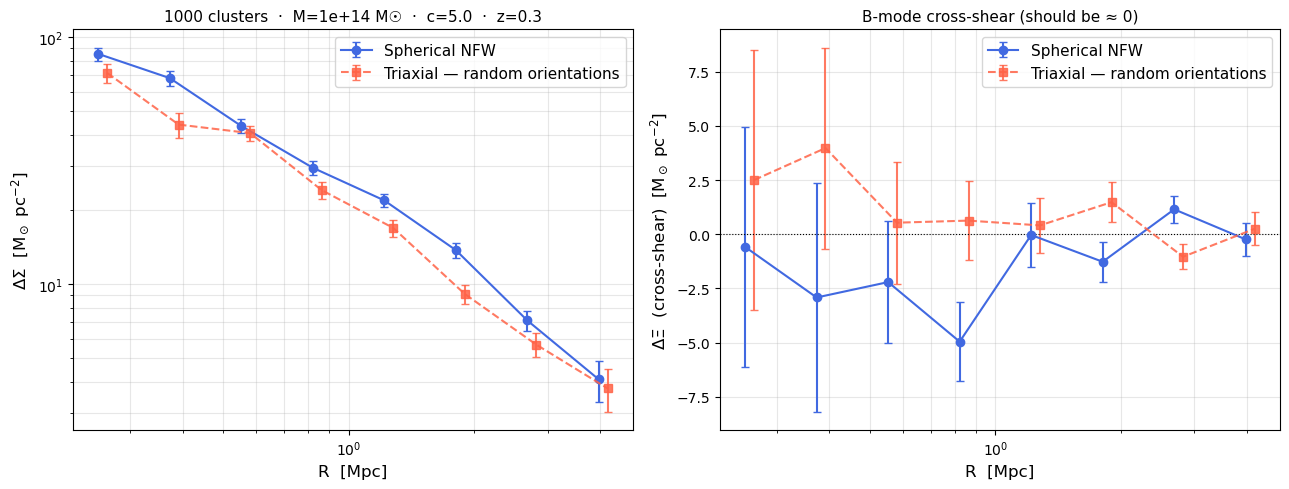

In [9]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# ── ΔΣ profiles ───────────────────────────────────────────────────────────────
ax = axes[0]
ax.errorbar(radii, sig_sph, yerr=err_sph,
            fmt='o-', color='royalblue', capsize=3,
            label='Spherical NFW')
ax.errorbar(radii * 1.05, sig_tri, yerr=err_tri,
            fmt='s--', color='tomato', capsize=3, alpha=0.85,
            label='Triaxial — random orientations')
ax.set_xscale('log')
ax.set_yscale('log')
ax.set_xlabel('R  [Mpc]', fontsize=12)
ax.set_ylabel(r'$\Delta\Sigma$  [M$_\odot$ pc$^{-2}$]', fontsize=12)
ax.set_title(
    f'{N_CLUSTERS} clusters  ·  M={M_LENS:.0e} M☉  ·  c={CONC}  ·  z={Z_LENS}',
    fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, which='both')

# ── Cross-shear B-mode ────────────────────────────────────────────────────────
ax = axes[1]
ax.errorbar(radii, xsig_sph, yerr=xerr_sph,
            fmt='o-', color='royalblue', capsize=3,
            label='Spherical NFW')
ax.errorbar(radii * 1.05, xsig_tri, yerr=xerr_tri,
            fmt='s--', color='tomato', capsize=3, alpha=0.85,
            label='Triaxial — random orientations')
ax.axhline(0, color='k', lw=0.8, ls=':')
ax.set_xscale('log')
ax.set_xlabel('R  [Mpc]', fontsize=12)
ax.set_ylabel(r'$\Delta\Xi$  (cross-shear)  [M$_\odot$ pc$^{-2}$]', fontsize=12)
ax.set_title('B-mode cross-shear (should be ≈ 0)', fontsize=11)
ax.legend(fontsize=11)
ax.grid(True, alpha=0.3, which='both')

plt.tight_layout()
plt.savefig('triaxial_vs_spherical_DSigma.png', dpi=150, bbox_inches='tight')
plt.show()

In [10]:
# Ratio ΔΣ_triaxial / ΔΣ_spherical per radial bin
print(f"{'R [Mpc]':>8}  {'ΔΣ_sph':>10}  {'ΔΣ_tri':>10}  {'ratio':>7}")
print("-" * 42)
for r_c, s, t in zip(radii, sig_sph, sig_tri):
    print(f"{r_c:8.3f}  {s:10.4f}  {t:10.4f}  {t/s:7.4f}")

 R [Mpc]      ΔΣ_sph      ΔΣ_tri    ratio
------------------------------------------
   0.251     85.4894     71.5710   0.8372
   0.373     68.2131     44.2269   0.6484
   0.553     43.6365     40.8453   0.9360
   0.821     29.5713     24.0099   0.8119
   1.218     21.8052     16.8818   0.7742
   1.808     13.7234      9.1244   0.6649
   2.683      7.1206      5.6886   0.7989
   3.981      4.1077      3.7791   0.9200
